___

<a href='https://oxiane-institut.com/'> <img src='../oxiane.jpg' /></a>
___

# Seaborn

## Distribution Plots

Let's discuss some plots that allow us to visualize the distribution of a dataset. These plots are:

* histplot
* jointplot
* pairplot
* rugplot
* kdeplot

These visualization techniques provide different ways to understand and analyze the distribution of data, each offering unique insights into the underlying patterns and relationships within the dataset.

___
## Imports

In [1]:
import seaborn as sns
%matplotlib inline

## Data

Seaborn comes with built-in datasets!

In [2]:
tips = sns.load_dataset('tips')

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [16]:
type(tips)

pandas.core.frame.DataFrame

## histplot

The distribution plot shows the distribution of a univariate set of observations.

<Axes: xlabel='total_bill', ylabel='Count'>

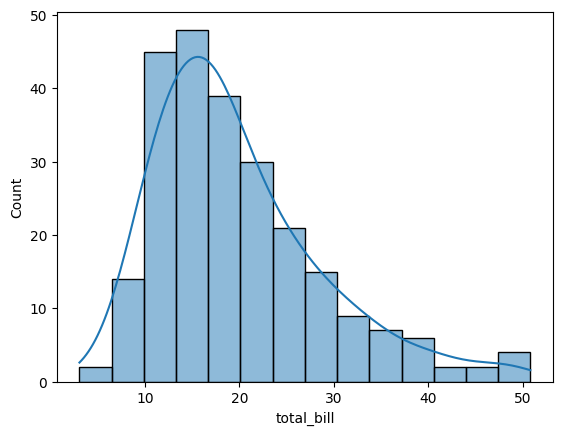

In [4]:
sns.histplot(data=tips, x='total_bill', kde=True)
# Using histplot with kde=True to replicate distplot functionality

To remove the KDE layer and display only the histogram, use:

<Axes: xlabel='total_bill', ylabel='Count'>

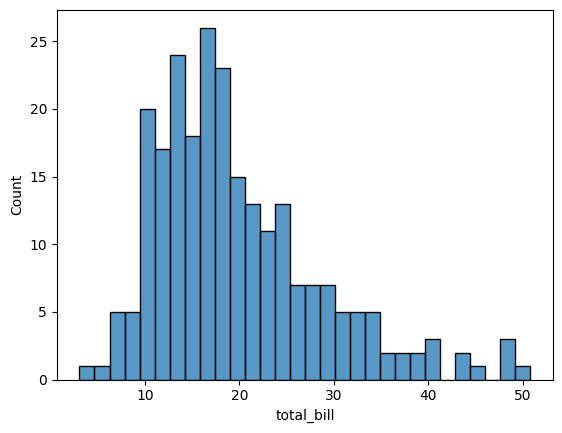

In [18]:
sns.histplot(tips["total_bill"], kde=False, bins=30)

## jointplot

jointplot() essentially allows you to match two distribution plots for bivariate data. With your choice of the **kind** parameter to compare:
* "scatter"
* "reg"
* "resid"
* "kde"
* "hex"

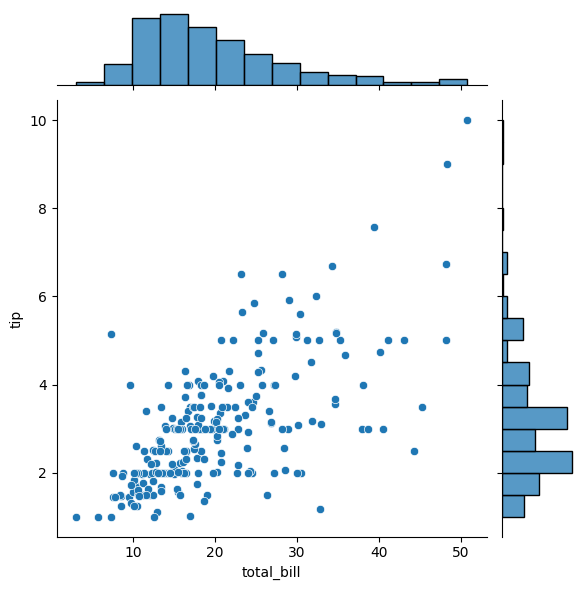

In [6]:
sns.jointplot(x='total_bill',y='tip',data=tips,kind='scatter')

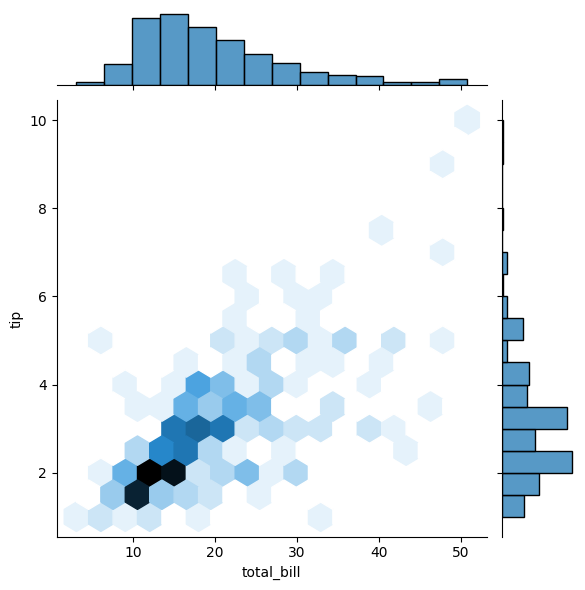

In [7]:
sns.jointplot(x='total_bill',y='tip',data=tips,kind='hex')

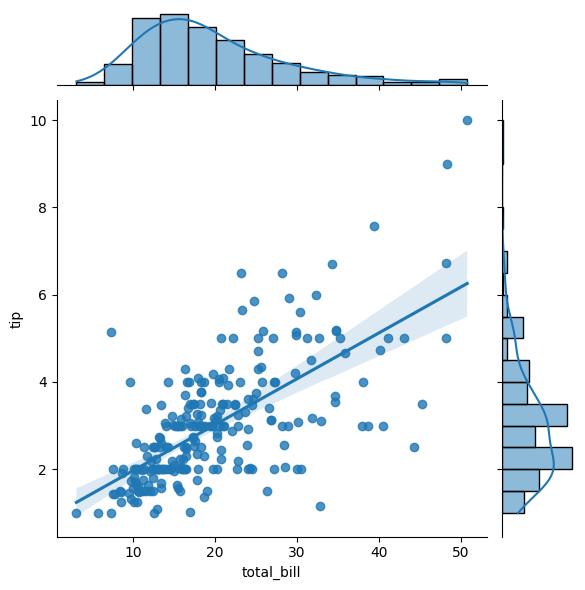

In [8]:
sns.jointplot(x='total_bill',y='tip',data=tips,kind='reg')

## pairplot

The pairplot function plots pairwise relationships across an entire dataframe (for numeric columns) and supports a color hue argument (for categorical columns).

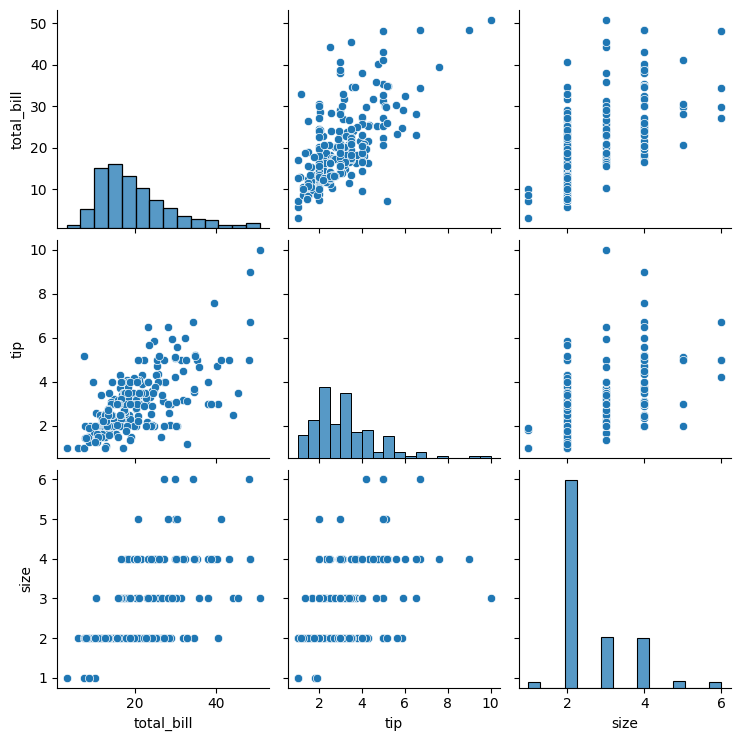

In [9]:
sns.pairplot(tips)

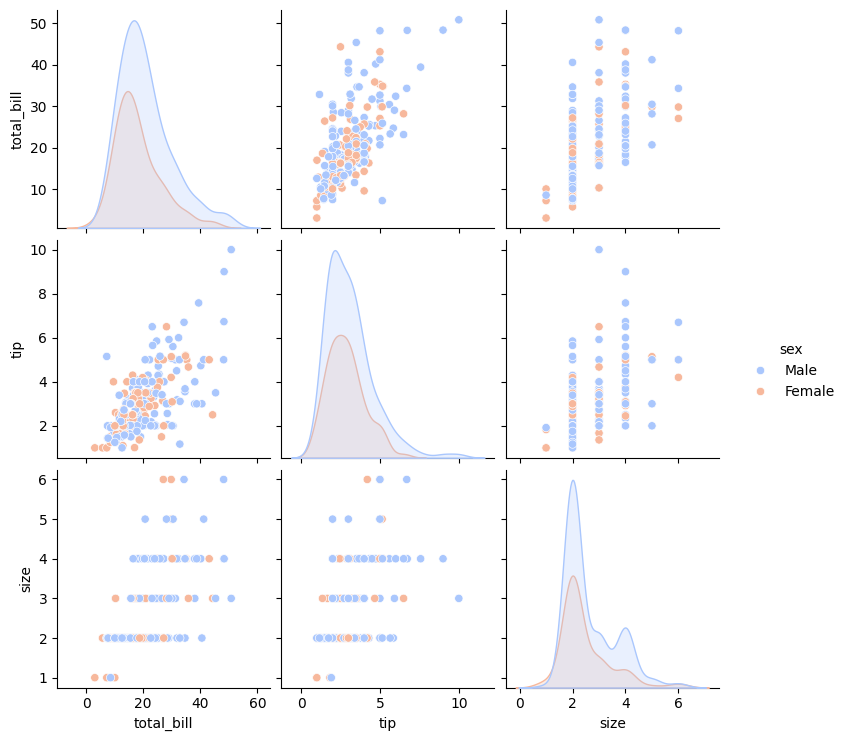

In [10]:
sns.pairplot(tips, hue='sex', palette='coolwarm')

## Rugplot

Rugplots are actually a very simple concept. They simply draw a dash for each point in a univariate distribution. They form the cornerstone of KDE plots:

<Axes: xlabel='total_bill'>

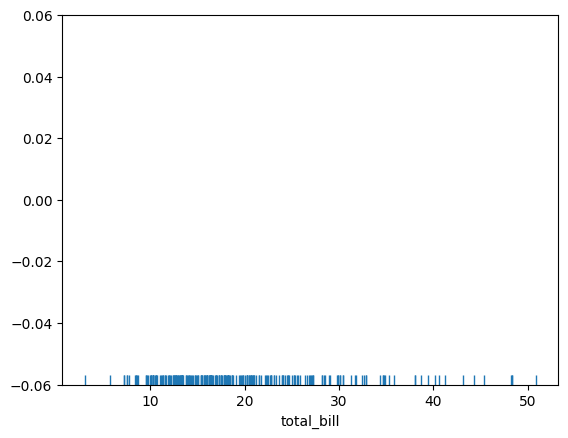

In [11]:
sns.rugplot(tips['total_bill'])

## kdeplot

KDE plots are [Kernel Density Estimation plots](http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth). These KDE plots replace each observation with a Gaussian (normal) distribution centered around that value. For example:

(0.0, 1.0)

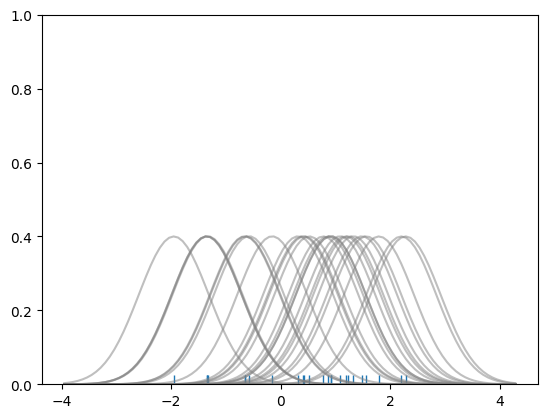

In [12]:
# Don't worry about understanding this code!
# It's just for the diagram below
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

#Create dataset
dataset = np.random.randn(25)

# Create another rugplot
sns.rugplot(dataset);

# Set up the x-axis for the plot
x_min = dataset.min() - 2
x_max = dataset.max() + 2

# 100 equally spaced points from x_min to x_max
x_axis = np.linspace(x_min,x_max,100)

# Set up the bandwidth, for info on this:
url = 'http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth'

bandwidth = ((4*dataset.std()**5)/(3*len(dataset)))**.2


# Create an empty kernel list
kernel_list = []

# Plot each basis function
for data_point in dataset:
    
    # Create a kernel for each point and append to list
    kernel = stats.norm(data_point,bandwidth).pdf(x_axis)
    kernel_list.append(kernel)
    
    #Scale for plotting
    kernel = kernel / kernel.max()
    kernel = kernel * .4
    plt.plot(x_axis,kernel,color = 'grey',alpha=0.5)

plt.ylim(0,1)

Text(0.5, 0.98, 'Sum of the Basis Functions')

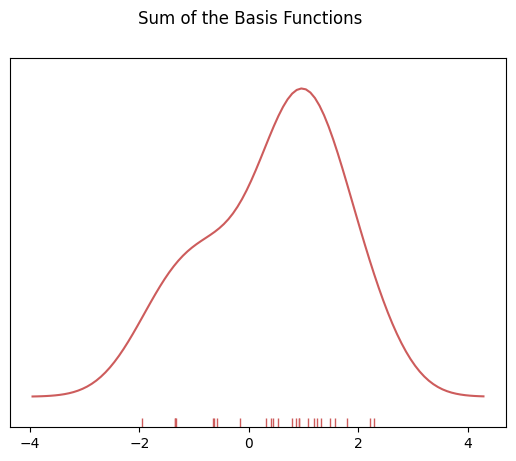

In [13]:
# To get the kde plot we can sum these basis functions.

# Plot the sum of the basis function
sum_of_kde = np.sum(kernel_list,axis=0)

# Plot figure
fig = plt.plot(x_axis,sum_of_kde,color='indianred')

# Add the initial rugplot
sns.rugplot(dataset,c = 'indianred')

# Get rid of y-tick marks
plt.yticks([])

# Set title
plt.suptitle("Sum of the Basis Functions")

Avec notre DataSet:

<Axes: xlabel='total_bill', ylabel='Density'>

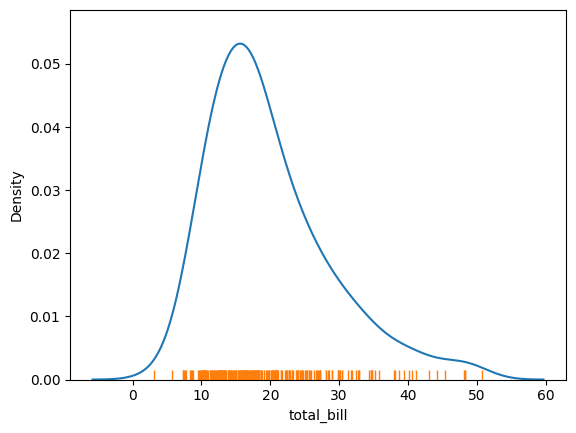

In [14]:
sns.kdeplot(tips['total_bill'])
sns.rugplot(tips['total_bill'])

<Axes: xlabel='tip', ylabel='Density'>

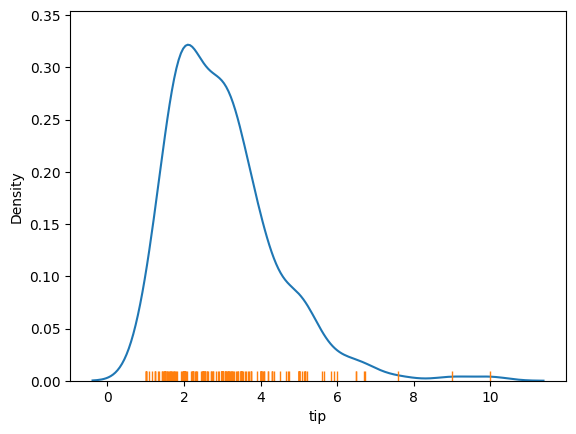

In [15]:
sns.kdeplot(tips['tip'])
sns.rugplot(tips['tip'])